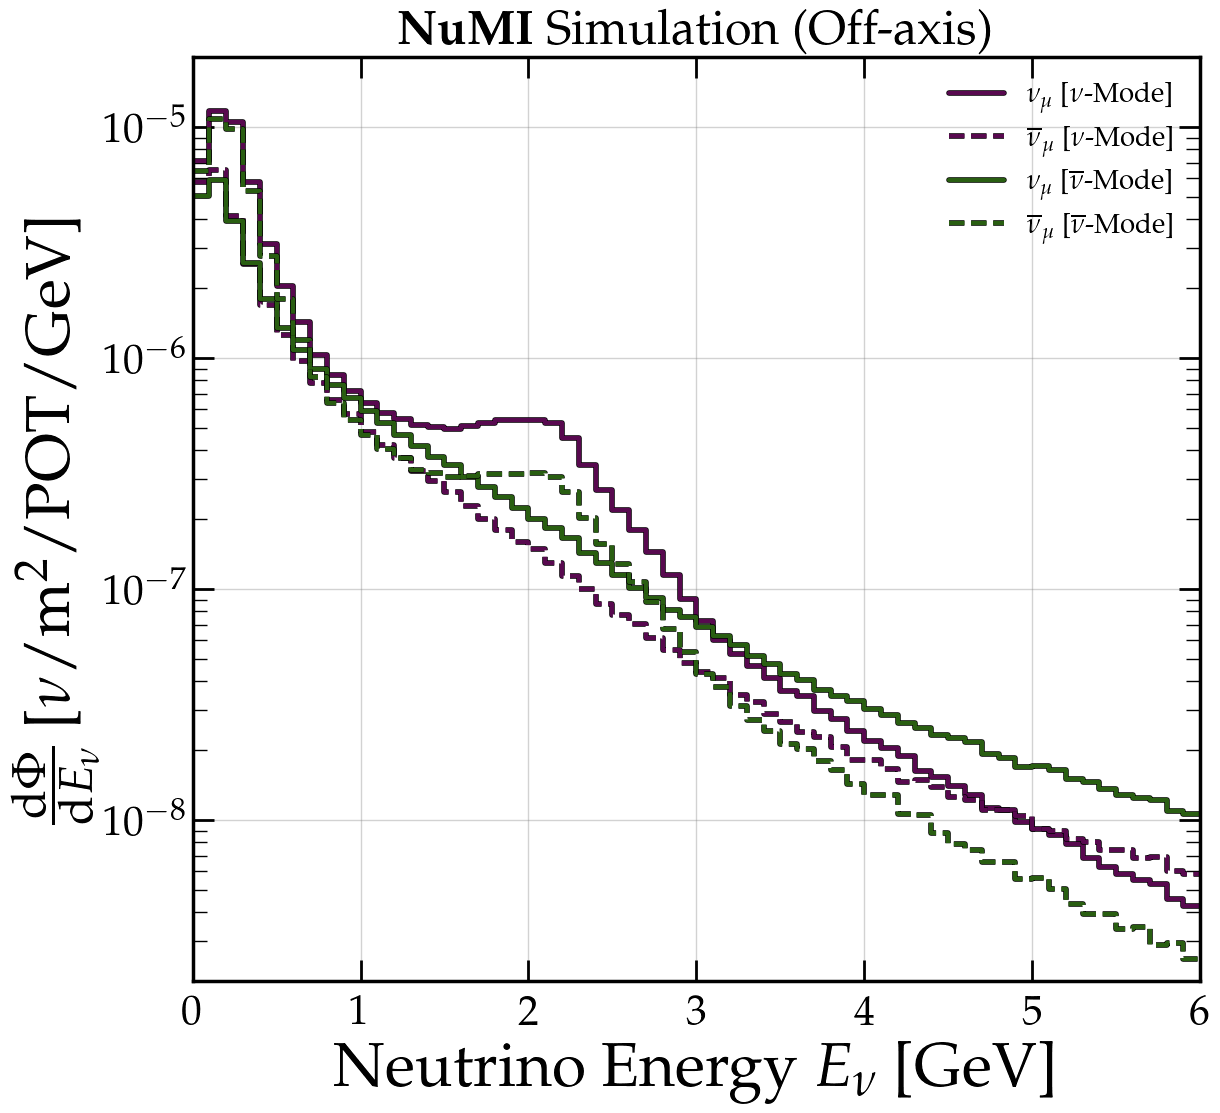

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import matplotlib
from scipy.integrate import simpson

plt.style.use('../Analysis/sty.mplstyle')

def StepFunction(xmin, xmax, y):
    x = np.concatenate((xmin[0:1], xmax))
    y = np.concatenate((y[0:1], y))
    return x, y

#===================================================================================================================
#==================================== (Anti)Neutrino Flux in (Anti)Neutrino Mode ===================================
#===================================================================================================================

Energy_NuMI_offaxis_numu_nuMode = np.loadtxt('Digitized_Dataset_NuMI_offaxis_numu_nuMode.txt', delimiter=',', usecols=0) # GeV
Flux_NuMI_offaxis_numu_nuMode = np.loadtxt('Digitized_Dataset_NuMI_offaxis_numu_nuMode.txt', delimiter=',', usecols=1) #numu/m^2/GeV/POT

Energy_NuMI_offaxis_numubar_nuMode = np.loadtxt('Digitized_Dataset_NuMI_offaxis_numubar_nuMode.txt', delimiter=',', usecols=0) # GeV
Flux_NuMI_offaxis_numubar_nuMode = np.loadtxt('Digitized_Dataset_NuMI_offaxis_numubar_nuMode.txt', delimiter=',', usecols=1) #numubar/m^2/GeV/POT

Energy_NuMI_offaxis_numu_AntinuMode = np.loadtxt('Digitized_Dataset_NuMI_offaxis_numu_AntinuMode.txt', delimiter=',', usecols=0) # GeV
Flux_NuMI_offaxis_numu_AntinuMode = np.loadtxt('Digitized_Dataset_NuMI_offaxis_numu_AntinuMode.txt', delimiter=',', usecols=1) #numu/m^2/GeV/POT

Energy_NuMI_offaxis_numubar_AntinuMode = np.loadtxt('Digitized_Dataset_NuMI_offaxis_numubar_AntinuMode.txt', delimiter=',', usecols=0) # GeV
Flux_NuMI_offaxis_numubar_AntinuMode = np.loadtxt('Digitized_Dataset_NuMI_offaxis_numubar_AntinuMode.txt', delimiter=',', usecols=1) #numubar/m^2/GeV/POT

# Data to create the list [E_min, Ehigh, Prob]
Energy_NuMI_offaxis_csv = np.linspace(6/120, 6*119/120, 60)
Elow_NuMI_offaxis_csv = Energy_NuMI_offaxis_csv - 0.05
Ehigh_NuMI_offaxis_csv = Energy_NuMI_offaxis_csv + 0.05

# Computing the total Flux
numu_total_flux_NuMI_offaxis_nuMode = simpson(Flux_NuMI_offaxis_numu_nuMode, Energy_NuMI_offaxis_numu_nuMode)
numubar_total_flux_NuMI_offaxis_nuMode = simpson(Flux_NuMI_offaxis_numubar_nuMode, Energy_NuMI_offaxis_numubar_nuMode)
numu_total_flux_NuMI_offaxis_AntinuMode = simpson(Flux_NuMI_offaxis_numu_AntinuMode, Energy_NuMI_offaxis_numu_AntinuMode)
numubar_total_flux_NuMI_offaxis_AntinuMode = simpson(Flux_NuMI_offaxis_numubar_AntinuMode, Energy_NuMI_offaxis_numubar_AntinuMode)

# Initialize to zero the normalized probabilities
numu_normProb_NuMI_offaxis_nuMode = np.zeros_like(Flux_NuMI_offaxis_numu_nuMode)
numubar_normProb_NuMI_offaxis_nuMode = np.zeros_like(Flux_NuMI_offaxis_numubar_nuMode)
numu_normProb_NuMI_offaxis_AntinuMode = np.zeros_like(Flux_NuMI_offaxis_numu_AntinuMode)
numubar_normProb_NuMI_offaxis_AntinuMode = np.zeros_like(Flux_NuMI_offaxis_numubar_AntinuMode)

#====================================== Compute the Normalized Probabilities =======================================

for i in range(len(numu_normProb_NuMI_offaxis_nuMode)):
    bin_width = Ehigh_NuMI_offaxis_csv[i] - Elow_NuMI_offaxis_csv[i]
    numu_normProb_NuMI_offaxis_nuMode[i] = Flux_NuMI_offaxis_numu_nuMode[i]*bin_width/numu_total_flux_NuMI_offaxis_nuMode

for i in range(len(numubar_normProb_NuMI_offaxis_nuMode)):
    bin_width = Ehigh_NuMI_offaxis_csv[i] - Elow_NuMI_offaxis_csv[i]
    numubar_normProb_NuMI_offaxis_nuMode[i] = Flux_NuMI_offaxis_numubar_nuMode[i]*bin_width/numubar_total_flux_NuMI_offaxis_nuMode

for i in range(len(numu_normProb_NuMI_offaxis_AntinuMode)):
    bin_width = Ehigh_NuMI_offaxis_csv[i] - Elow_NuMI_offaxis_csv[i]
    numu_normProb_NuMI_offaxis_AntinuMode[i] = Flux_NuMI_offaxis_numu_AntinuMode[i]*bin_width/numu_total_flux_NuMI_offaxis_AntinuMode

for i in range(len(numubar_normProb_NuMI_offaxis_AntinuMode)):
    bin_width = Ehigh_NuMI_offaxis_csv[i] - Elow_NuMI_offaxis_csv[i]
    numubar_normProb_NuMI_offaxis_AntinuMode[i] = Flux_NuMI_offaxis_numubar_AntinuMode[i]*bin_width/numubar_total_flux_NuMI_offaxis_AntinuMode

#================================================== Writing to CSV =================================================
with open("../csv/Fluxes/ICARUS_NuMode.txt", mode='w', newline="") as file:
    file.write("#Elo: Lower bin edge in GeV \n")
    file.write("#Ehi: Upper bin edge in GeV \n")
    file.write("#numu flux    (numu/m^2/proton-on-target/GeV) \n")
    file.write("#numubar flux (numubar/m^2/proton-on-target/GeV \n")
    file.write("#        Elo        Ehi            numu                numubar \n")
    for e_low, e_high, numu, numubar in (zip(Elow_NuMI_offaxis_csv, Ehigh_NuMI_offaxis_csv, Flux_NuMI_offaxis_numu_nuMode, Flux_NuMI_offaxis_numubar_nuMode)):
        file.write(f"\t {e_low:.4f} \t {e_high:.4f} \t {numu} \t {numubar} \n")

with open("../csv/Fluxes/ICARUS_AnuMode.txt", mode='w', newline="") as file:
    file.write("#Elo: Lower bin edge in GeV \n")
    file.write("#Ehi: Upper bin edge in GeV \n")
    file.write("#numu flux    (numu/m^2/proton-on-target/GeV) \n")
    file.write("#numubar flux (numubar/m^2/proton-on-target/GeV \n")
    file.write("#        Elo        Ehi            numu                numubar \n")
    for e_low, e_high, numu, numubar in (zip(Elow_NuMI_offaxis_csv, Ehigh_NuMI_offaxis_csv, Flux_NuMI_offaxis_numu_AntinuMode, Flux_NuMI_offaxis_numubar_AntinuMode)):
        file.write(f"\t {e_low:.4f} \t {e_high:.4f} \t {numu} \t {numubar} \n")
        
with open("../csv/Fluxes/NormProb/nu_NormProb_ICARUS_offaxis_nuMode.txt", mode='w', newline="") as file:
    file.write("########################################################################################## \n")
    file.write(f"#####\t Integrated Neutrino Flux (Neutrino Mode): {numu_total_flux_NuMI_offaxis_nuMode} m^-2 POT^-1 \n")
    file.write("########################################################################################## \n")
    for e_low, e_high, p_norm in (zip(Elow_NuMI_offaxis_csv, Ehigh_NuMI_offaxis_csv, numu_normProb_NuMI_offaxis_nuMode)):
        file.write(f"\t {e_low:.4f}, \t {e_high:.4f}, \t {p_norm:.22f}, \n")
        
with open("../csv/Fluxes/NormProb/antinu_NormProb_ICARUS_offaxis_nuMode.txt", mode='w', newline="") as file:
    file.write("########################################################################################## \n")
    file.write(f"#####\t Integrated AntiNeutrino Flux (Neutrino Mode): {numubar_total_flux_NuMI_offaxis_nuMode} m^-2 POT^-1 \n")
    file.write("########################################################################################## \n")
    for e_low, e_high, p_norm in (zip(Elow_NuMI_offaxis_csv, Ehigh_NuMI_offaxis_csv, numubar_normProb_NuMI_offaxis_nuMode)):
        file.write(f"\t {e_low:.4f}, \t {e_high:.4f}, \t {p_norm:.22f}, \n")

with open("../csv/Fluxes/NormProb/nu_NormProb_ICARUS_offaxis_antinuMode.txt", mode='w', newline="") as file:
    file.write("########################################################################################## \n")
    file.write(f"#####\t Integrated Neutrino Flux (AntiNeutrino Mode): {numu_total_flux_NuMI_offaxis_AntinuMode} m^-2 POT^-1 \n")
    file.write("########################################################################################## \n")
    for e_low, e_high, p_norm in (zip(Elow_NuMI_offaxis_csv, Ehigh_NuMI_offaxis_csv, numu_normProb_NuMI_offaxis_AntinuMode)):
        file.write(f"\t {e_low:.4f}, \t {e_high:.4f}, \t {p_norm:.22f}, \n")

with open("../csv/Fluxes/NormProb/antinu_NormProb_ICARUS_offaxis_antinuMode.txt", mode='w', newline="") as file:
    file.write("########################################################################################## \n")
    file.write(f"#####\t Integrated AntiNeutrino Flux (AntiNeutrino Mode): {numubar_total_flux_NuMI_offaxis_AntinuMode} m^-2 POT^-1 \n")
    file.write("########################################################################################## \n")
    for e_low, e_high, p_norm in (zip(Elow_NuMI_offaxis_csv, Ehigh_NuMI_offaxis_csv, numubar_normProb_NuMI_offaxis_AntinuMode)):
        file.write(f"\t {e_low:.4f}, \t {e_high:.4f}, \t {p_norm:.22f}, \n")

#===================================================================================================================
#================================= Plotting the neutrino and anti-neutrino fluxes ==================================
#===================================================================================================================

fig = plt.figure()
ax = fig.add_subplot()
patheff = [pe.Stroke(linewidth=4, foreground='k'), pe.Normal()]

data_numu_nuMode = StepFunction(Elow_NuMI_offaxis_csv, Ehigh_NuMI_offaxis_csv, Flux_NuMI_offaxis_numu_nuMode)
data_numubar_nuMode = StepFunction(Elow_NuMI_offaxis_csv, Ehigh_NuMI_offaxis_csv, Flux_NuMI_offaxis_numubar_nuMode)
data_numu_AntinuMode = StepFunction(Elow_NuMI_offaxis_csv, Ehigh_NuMI_offaxis_csv, Flux_NuMI_offaxis_numu_AntinuMode)
data_numubar_AntinuMode = StepFunction(Elow_NuMI_offaxis_csv, Ehigh_NuMI_offaxis_csv, Flux_NuMI_offaxis_numubar_AntinuMode)

ax.step(data_numu_nuMode[0], data_numu_nuMode[1], ls='-', color='#58094F', label=r'$\nu_\mu$ [$\nu$-Mode]', path_effects=patheff)
ax.step(data_numubar_nuMode[0], data_numubar_nuMode[1], ls='--', color='#58094F', label=r'$\overline{\nu}_\mu$ [$\nu$-Mode]', path_effects=patheff)
ax.step(data_numu_AntinuMode[0], data_numu_AntinuMode[1], ls='-', color='#295E11', label=r'$\nu_\mu$ [$\overline{\nu}$-Mode]', path_effects=patheff)
ax.step(data_numubar_AntinuMode[0], data_numubar_AntinuMode[1], ls='--', color='#295E11', label=r'$\overline{\nu}_\mu$ [$\overline{\nu}$-Mode]', path_effects=patheff)

ax.legend(fontsize=20, loc='upper right', frameon=False, framealpha=1, edgecolor='k', fancybox=True)
ax.set_yscale('log')
ax.set_ylim([2e-9, 2e-5])
ax.set_xlim([0,6])

ax.xaxis.grid(True, ls='-', which='major', color='gray', alpha=0.35)
ax.yaxis.grid(True, ls='-', which='major', color='gray', alpha=0.35)

ax.set_title(r'{\bf NuMI} Simulation (Off-axis)')
ax.set_ylabel(r'$\frac{\mathrm{d} \Phi}{\mathrm{d} E_\nu}$  [$\nu$/m$^2$/POT/GeV]')
ax.set_xlabel(r'Neutrino Energy $E_\nu$ [GeV]')

plt.savefig('../Plots/Figures_PDF/ICARUS/ICARUS_Flux.pdf', transparent=False, bbox_inches='tight')
plt.savefig('../Plots/Figures_PNG/ICARUS/ICARUS_Flux.png', transparent=False, bbox_inches='tight')